# Model Training

In [8]:
# basic import 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default') # for better visualization
import seaborn as sns 



# Modeling 

from sklearn.metrics import mean_squared_error , r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from xgboost import XGBRegressor
import warnings 
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/Users/himanshuberi/Desktop/GITHUB_PROJECTS/GENERIC_ML_PROJECT/notebook/data/StudentPerformance.csv")
# Naming convention problem 

In [11]:
df = pd.read_csv('/Users/himanshuberi/Desktop/GITHUB_PROJECTS/Generic_ML_Project/notebook/data/StudentsPerformance.csv')

# Preparing X and Y variable 

In [16]:
X = df.drop(columns = ['math score'])

In [17]:
y = df['math score']

In [19]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [21]:
# Create column transformers with 3 type of Transformer
num_features = X.select_dtypes(exclude=['str']).columns
cat_features = X.select_dtypes(include=['str']).columns


numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    [
        ("One_hot_encoder",categorical_transformer,cat_features),
        ("Standard_scaler",numeric_transformer,num_features),
    ]
)

In [22]:
X = preprocessor.fit_transform(X)

In [ ]:
X.shape
# Columns have been transformed and increased in number due to one-hot encoding

(1000, 19)

In [24]:
# Seperate the data into training and testing datasets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

# Create and Evaluate function to give all metrics after model Training 


In [32]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, mse, r2

In [33]:
from sklearn.tree import DecisionTreeRegressor 

In [35]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "adaboost": AdaBoostRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "SVM": SVR(),
    "k-Nearest Neighbors": KNeighborsRegressor()
}

model_list = []
r2_scores = []

for i in range(len(list(models))):
    model   = list(models.values())[i]
    model.fit(X_train, y_train)  # Train the model
    
    # Make Predictions 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evalaute train and test performance:
    model_train_mae, model_train_mse , model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse , model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Store results
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    
    print('Model Performance for training data:')
    print(f"MAE: {model_train_mae}, MSE: {model_train_mse}, R2: {model_train_r2}")
    print('Model Performance for test data:')
    print(f"MAE: {model_test_mae}, MSE: {model_test_mse}, R2: {model_test_r2}")
    r2_scores.append(model_test_r2)
    print('='*35 )
    print('\n')

Linear Regression
Model Performance for training data:
MAE: 4.266711846071957, MSE: 28.33487038064859, R2: 0.8743172040139593
Model Performance for test data:
MAE: 4.214763142474852, MSE: 29.095169866715516, R2: 0.8804332983749564


Random Forest
Model Performance for training data:
MAE: 1.8179385416666667, MSE: 5.3020540078125, R2: 0.9764820885637093
Model Performance for test data:
MAE: 4.5598, MSE: 35.26231416666667, R2: 0.855089397453642


Ridge Regression
Model Performance for training data:
MAE: 4.2649878237259795, MSE: 28.337788233082446, R2: 0.8743042615212909
Model Performance for test data:
MAE: 4.211100688014258, MSE: 29.056272192348246, R2: 0.880593148502874


Lasso Regression
Model Performance for training data:
MAE: 5.206302661246526, MSE: 43.47840400585579, R2: 0.8071462015863456
Model Performance for test data:
MAE: 5.157881810347763, MSE: 42.50641683841162, R2: 0.8253197323627852


adaboost
Model Performance for training data:
MAE: 4.760446371593097, MSE: 33.8333326045

In [36]:
# Results : 
pd.DataFrame({"Model": model_list, "R2_Score": r2_scores})

,Model,R2_Score
0,Linear Regression,0.880433
1,Random Forest,0.855089
2,Ridge Regression,0.880593
3,Lasso Regression,0.825320
4,adaboost,0.845792
5,Decision Tree,0.740875
6,SVM,0.728600
7,k-Nearest Neighbors,0.783754


In [37]:
# Going with Linear Regression: 
linear_regression = LinearRegression(fit_intercept=True)
linear_regression.fit(X_train, y_train)
y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test) 
score = r2_score(y_test, y_test_pred)*100
print(f"R2 Score for Linear Regression: {score}")

R2 Score for Linear Regression: 88.04332983749565


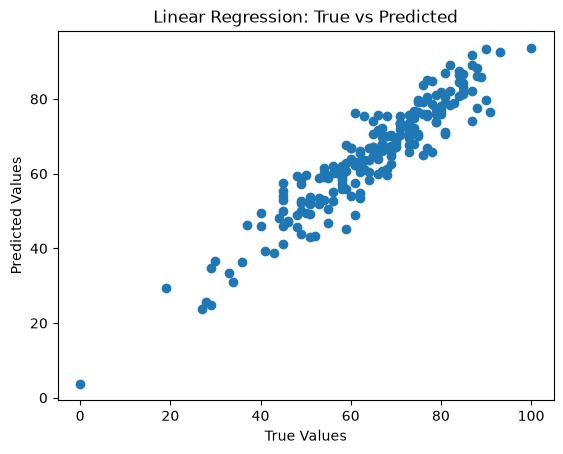

In [38]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: True vs Predicted")
plt.show()

<Axes: xlabel='math score'>

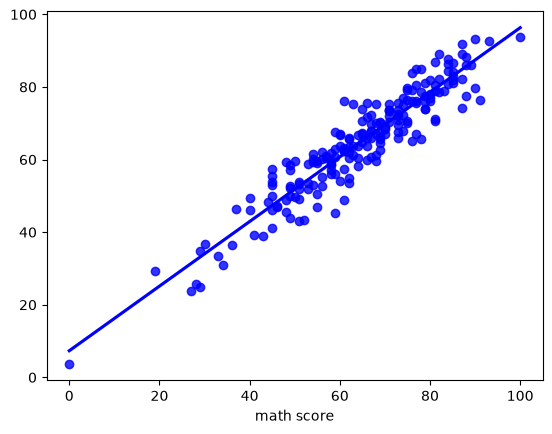

In [39]:
sns.regplot(x=y_test, y=y_test_pred,ci= None,color = 'blue')

# Difference between actual and predicted ones 


In [40]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred,'Difference': y_test - y_test_pred})
pred_df.head()

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
